# **Tugas Akhir IF5250 Deep Learning**

# **Audio-CRNN-Benchmarking-ESC-50**

||Identitas|
|--|--|
|Nama|Siti Ramadina Goethe K.|
|NIM|15322001|
|Kode Mahasiswa|MHS-06|
|Dataset|[ESC-50](https://github.com/karolpiczak/ESC-50)|

# Bagian 1:  Persiapan Awal

## 1.1 Import Libraries & Setup Random Seed

In [ ]:
import os
import torch
import torch.nn as nn
import torchaudio
import torchaudio.functional as F
import torchaudio.transforms as T
from torch.utils.data import Dataset, DataLoader
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Reproducibility
torch.manual_seed(42)
np.random.seed(42)

print("Setup complete.")

Setup complete.


In [ ]:
# Dictionary config.yaml untuk menyimpan hyperparameter
config = {

}

## 1.2 Download dan Load Dataset ESC-50

In [ ]:
# Unduh otomatis dari GitHub
if not os.path.exists('ESC-50-master'):
  !wget https://github.com/karoldvl/ESC-50/archive/master.zip
  !unzip -oq master.zip
  print("Selesai mengunduh dataset ESC-50 dari GitHub")
else:
  print("Dataset ESC-50 sudah tersedia.")


--2026-05-17 09:41:18--  https://github.com/karoldvl/ESC-50/archive/master.zip
Resolving github.com (github.com)... 20.27.177.113
Connecting to github.com (github.com)|20.27.177.113|:443... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://github.com/karolpiczak/ESC-50/archive/master.zip [following]
--2026-05-17 09:41:19--  https://github.com/karolpiczak/ESC-50/archive/master.zip
Reusing existing connection to github.com:443.
HTTP request sent, awaiting response... 302 Found
Location: https://codeload.github.com/karolpiczak/ESC-50/zip/refs/heads/master [following]
--2026-05-17 09:41:19--  https://codeload.github.com/karolpiczak/ESC-50/zip/refs/heads/master
Resolving codeload.github.com (codeload.github.com)... 20.27.177.114
Connecting to codeload.github.com (codeload.github.com)|20.27.177.114|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified [application/zip]
Saving to: ‘master.zip’

master.zip              [ 

In [ ]:
# Baca data
csv_path = '/content/ESC-50-master/meta/esc50.csv'
wav_dir_path = '/content/ESC-50-master/audio'

df = pd.read_csv(csv_path)
print(f"Total data: {len(df)} sampel")
df.head()

Total data: 2000 sampel


,filename,fold,target,category,esc10,src_file,take
0,1-100032-A-0.wav,1,0,dog,True,100032,A
1,1-100038-A-14.wav,1,14,chirping_birds,False,100038,A
2,1-100210-A-36.wav,1,36,vacuum_cleaner,False,100210,A
3,1-100210-B-36.wav,1,36,vacuum_cleaner,False,100210,B
4,1-101296-A-19.wav,1,19,thunderstorm,False,101296,A


In [ ]:
# Split data

## 1.3 Konversi File Audio ke Mel-Spectogram

In [ ]:
# Konversi
mel_spectogram = T.MelSpectrogram(
    sample_rate = 22050,
    n_fft = 1024,
    hop_length = 512,
    n_mels = 64,
)

# Ubah audio ke Log-Mel-Spectogram
def log_mel_spec(path):
  waveform, sample_rate = torchaudio.load(path)
  mel_spec = mel_spectogram(waveform)
  log_mel = T.AmplitudeToDB(mel_spec, top_db=80)(mel_spec)
  return log_mel[0]


In [ ]:
# Kelas ESC-50 Dataset
class ESC50Dataset(Dataset):
  def __init__(self, df, wav_dir, transform=None):
    self.df = df
    self.wav_dir = wav_dir
    self.transform = transform

  def __len__(self):
    return len(self.df)

  def __getitem__(self, idx):
    wav_name = self.df.iloc[idx]['filename']
    label = self.df.iloc[idx]['target']
    audio_path = os.path.join(self.wav_dir, wav_name)

    # Ambil mel-spec
    mel_spec = log_mel_spec(audio_path)
    mel_spec = mel_spec.unsqueeze(0) # tambah dimensi channel (1, freq, t)
    return mel_spec, label

dataset = ESC50Dataset(df, wav_dir_path)

Id: 1126 | Label: 6 | Kategori: hen
Ukuran Tensor Spectogram: torch.Size([1, 64, 431]) (Ch, Mel, t)


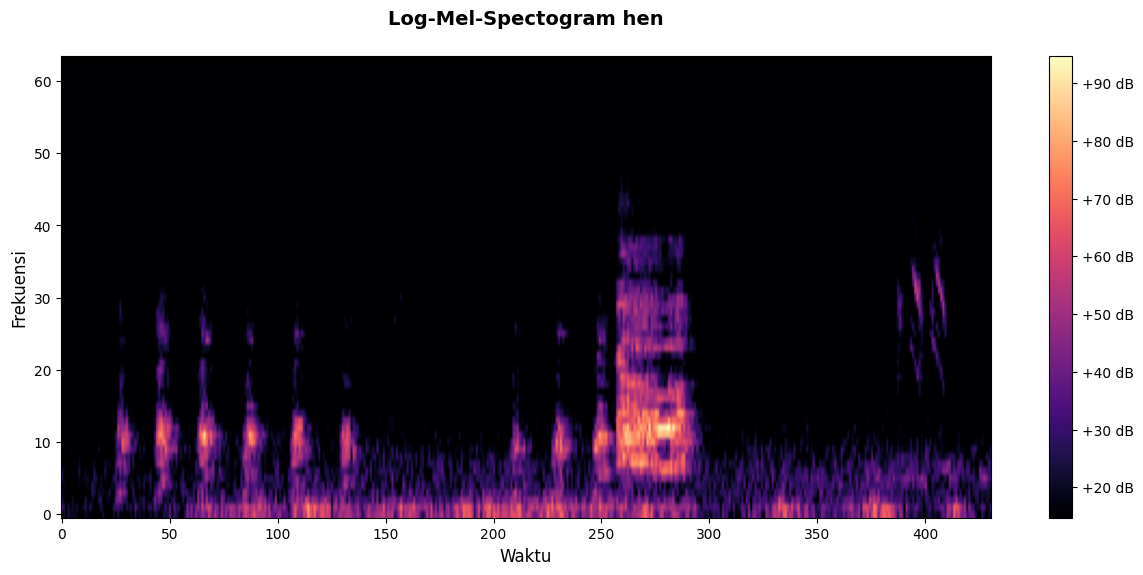

In [ ]:
# Contoh representasi visual dari suara (spektorgram)

# Pilih satu sampel acak
idx = np.random.randint(0, len(dataset))
mel, label = dataset[idx]
category = df.iloc[idx]['category']

print(f"Id: {idx} | Label: {label} | Kategori: {category}")
print(f"Ukuran Tensor Spectogram: {mel.shape} (Ch, Mel, t)")

plt.figure(figsize=(15,6))
plt.imshow(mel[0].numpy(), origin='lower', aspect='auto', cmap='magma')
plt.title(f"Log-Mel-Spectogram {category}", fontsize=14, y=1.05, fontweight='bold')
plt.xlabel("Waktu", fontsize=12)
plt.ylabel("Frekuensi", fontsize=12)
plt.colorbar(format="%+2.0f dB") # tambah satuan pada bar
plt.show()


## 1.4 Implementasi 5-Fold Cross-Validation

In [ ]:
# Implementasi 5-Fold Cross-Validation
# Fold 1-4 train
# Fold 5 test

## 1.5 Data Loader

In [ ]:
# DataLoader (Training, Validation, Test)

# Bagian 2: Arsitektur Model

[Boddapati, 2017](https://github.com/bkasvenkatesh/Classifying-Environmental-Sounds-with-Image-Networks/blob/master/CRNN.py)

## Model Utama: CRNN

In [ ]:
# Kelas CNN dan RNN
class CRNN(nn.Module):
  def __init__(self, input_size, hidden_size, num_layers, num_classes=50):
    super(CRNN, self).__init__()
    self.hidden_size = hidden_size
    self.num_layers = num_layers

    # Model CNN untuk ekstraksi fitur
    self.cnn = nn.Sequential(
        # Layer 1
        nn.Conv2d(1, 64, kernel_size=3, stride=1, padding=1),
        nn.BatchNorm2d(64),
        nn.ReLU(inplace=True),
        nn.MaxPool2d(kernel_size=2, stride=2),
        # Layer 2
        nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1),
        nn.BatchNorm2d(128),
        nn.ReLU(inplace=True),
        nn.MaxPool2d(kernel_size=4, stride=4, padding=1),
        # Layer 3
        nn.Conv2d(128, 256, )
        nn.BatchNorm2d(256),
        nn.ReLU(inplace=True),
        nn.MaxPool2d(kernel_size=2, stride=2),
        # Layer 4
        nn.Conv2d(128, 256, kernel_size=3, stride=1, padding=1),
        nn.BatchNorm2d(256),
        nn.ReLU(inplace=True),

    )

    # Model sekuensial RNN --> GRU
    self.rnn = nn.GRU(
        input_size,
        hidden_size,
        num_layers,
        batch_first=True,
        bidirectional=True
    )

    # Classifier
    self.classifier = nn.Linear(hidden_size*2, num_classes)

  def forward(self, x):
    x = self.cnn(x)




## Model Pembanding 1 (Baseline): ResNet-18

In [ ]:
# Adaptasi ResNet-18 untuk input spectogram (1 ch)

## Model Pembanding 2 (SOTA): ViT Audio

In [ ]:
# Implementasi Vision Transformer untuk audio

# Bagian 3: Training Pipeline

In [ ]:
# Kelas fungsi pelatihan dan evaluasi

In [ ]:
TODO: Loop Training untuk 3 model.
TODO: Simpan Checkpoint model terbaik (.pth) berdasarkan akurasi validasi.
TODO: Simpan kurva Loss dan Akurasi (train vs val) untuk laporan.

# Bagian 4: Evaluasi dan Benchmarking

Evaluasi semua model pada Test Set (Fold 5).
TODO: Hitung Accuracy, Precision, Recall, F1-Score (Weighted).
TODO: Buat Confusion Matrix untuk ketiga model.
TODO: Ekspor hasil ke file metrics.json sesuai format spesifikasi hal. 12.

# Bagian 5: Representational Similarity Analysis (RSM)

TODO: Load "Benchmark Set" (400 audio manifest dari dosen).
TODO: Ekstrak Embedding dari penultimate layer untuk tiap model.
TODO: Hitung Cosine Similarity Matrix (N x N).
TODO: Visualisasi Heatmap RSM dan simpan sebagai .png.


# Bagian 6: Visualisasi Saliency/Attention

TODO: Pilih 20-30 sampel dari benchmark set.
TODO: Implementasi Saliency Map (untuk CRNN/ResNet) dan Attention Map (untuk ViT).
TODO: Simpan visualisasi untuk dibandingkan di laporan.

# Bagian 7: Ekspor Folder

TODO: Script otomatis untuk membuat struktur folder sesuai halaman 11 (model_utama, model_pembanding_1, dll).
TODO: Zip semua folder untuk diunduh.